PREGUNTA DE TESIS:
  "¿Cuáles son los factores [socio-económicos/técnicos/ambientales]
   que explican la variabilidad en [variable Y]?"

VARIABLE DEPENDIENTE (Y):
  • Nombre:  _______________
  • Tipo:    ☐ Continua  ☐ Conteo  ☐ Proporción  ☐ Binaria
  • Rango:   Min __ a Max __
  • Unidades: ______________
  • Distribución esperada: ☐ Normal  ☐ Sesgada  ☐ Cero-inflada

VARIABLES INDEPENDIENTES (X) - mínimo 3:
  X₁: ____________ (tipo numérica/categórica, por qué importa)
  X₂: ____________
  X₃: ____________
  X₄ (si aplica): ____________

DATOS:
  • Fuente: ☐ Propia  ☐ Secundaria  ☐ Simulados
  • N (tamaño muestra): ___
  • Problemas conocidos: (ej. ausentes, outliers, etc.)

# CHECKLIST PERSONALIZADO - Tu Análisis

## ✅ Preparación de Datos
- [ ] Cargar dataset desde Google Drive (mount)
- [ ] Verificar ausentes: df.isnull().sum()
- [ ] Estadísticas descriptivas (describe, dtypes)
- [ ] Gráficos exploratorios (distribuciones, scatter)

## ✅ Especificación del Modelo
- [ ] Modelo base: Y ~ X₁ + X₂ + X₃
- [ ] Ajustar modelo con ols()
- [ ] Interpretar coeficientes (en contexto de tu pregunta)

## ✅ Diagnósticos Críticos para TI
- [ ] Normalidad: ¿Shapiro-Wilk p < 0.05?
      → Si NO: Probar log(Y) porque Y es [sesgada/cero-inflada]
- [ ] Multicolinealidad: VIF de X₁ (correlation con X₂ = 0.xx)
      → Si VIF > 5: Considerar [eliminar/PCA/Ridge]
- [ ] Homocedasticidad: Levene test
      → Si falla: Usar WLS ponderado por [variable Z]
- [ ] Outliers: Cook's D > 0.xx
      → Obs IDs: [números] → Verificar si válidas

## ✅ Transformaciones Recomendadas
- [ ] Probar Box-Cox lambda = __
- [ ] Comparar Shapiro-Wilk (original vs transformado)

## ✅ Tabla de Resultados (formato APA)
- [ ] Modelo: Y ~ X₁ + X₂ + X₃
- [ ] N = __, R² = __, F = __, p < 0.001
- [ ] Coeficientes + IC 95% + p-values
- [ ] Notas: supuestos [OK/Condicional/Violado]

## ✅ Figuras para Entrega (3 mínimo)
- [ ] Scatter + línea ajustada (Y vs X₁)
- [ ] 4-panel diagnósticos (residuales, Q-Q, S-L, secuencia)
- [ ] Matriz correlaciones predictores

In [10]:
# 1. INSTALACIÓN Y CARGA DE LIBRERÍAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Configuración de visualización
warnings.filterwarnings('ignore')
plt.style.use('ggplot') # Estilo estándar compatible
sns.set_theme(style="whitegrid")
%matplotlib inline

print("="*80)
print("🎯 LABORATORIO: REGRESIÓN LINEAL (SP-8502)")
print("✓ Librerías cargadas con éxito")
print("="*80)

🎯 LABORATORIO: REGRESIÓN LINEAL (SP-8502)
✓ Librerías cargadas con éxito


In [11]:
# 2. GENERACIÓN DEL DATASET SINTÉTICO
print("\n[PARTE 1] Generación de Datos: Pesquerías Artesanales")

np.random.seed(42)
n = 150

# Variables independientes
datos_simulados = {
    'id_pescador': np.arange(1, n+1),
    'horas_faena': np.random.normal(6.5, 1.2, n),
    'tamanio_embarcacion_m': np.random.normal(7.2, 2.1, n),
    'experiencia_anios': np.random.uniform(1, 45, n),
    'temperatura_agua_C': np.random.normal(24.5, 1.8, n),
}

# Proceso Generador de Datos (DGP)
beta_0, beta_1, beta_2, beta_3 = 15.0, 8.5, 3.2, 0.4
epsilon = np.random.normal(0, 5.0, n)

# Variable dependiente (Y)
captura_kg = (beta_0 +
              beta_1 * datos_simulados['horas_faena'] +
              beta_2 * datos_simulados['tamanio_embarcacion_m'] +
              beta_3 * datos_simulados['experiencia_anios'] +
              epsilon)

datos_simulados['captura_kg'] = np.maximum(captura_kg, 5) # Evitar valores negativos
df = pd.DataFrame(datos_simulados)

print(f"✓ Dataset creado: {df.shape[0]} filas x {df.shape[1]} columnas")
display(df.head())


[PARTE 1] Generación de Datos: Pesquerías Artesanales
✓ Dataset creado: 150 filas x 6 columnas


,id_pescador,horas_faena,tamanio_embarcacion_m,experiencia_anios,temperatura_agua_C,captura_kg
0,1,7.096057,7.726035,13.409521,23.689882,107.091618
1,2,6.334083,7.927541,8.807340,25.621130,95.671387
2,3,7.277226,5.771948,34.027049,22.578283,106.499445
3,4,8.327636,7.687733,36.500729,24.243717,122.823150
4,5,6.219016,7.815452,44.582226,24.716532,112.676234


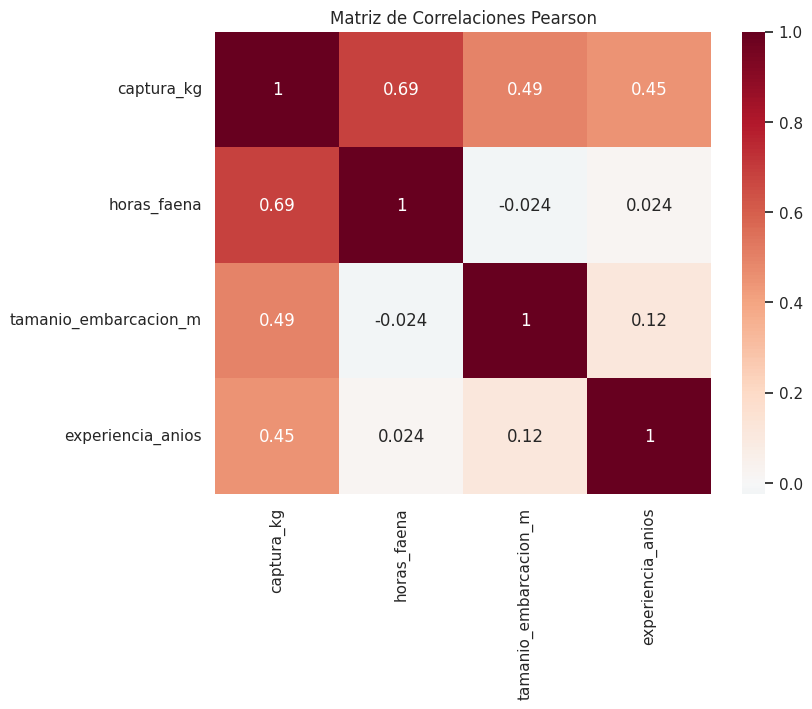

In [12]:
# 3. MATRIZ DE CORRELACIONES
cols_analisis = ['captura_kg', 'horas_faena', 'tamanio_embarcacion_m', 'experiencia_anios']
matriz_corr = df[cols_analisis].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='RdBu_r', center=0)
plt.title('Matriz de Correlaciones Pearson')
plt.show()

In [13]:
# 4. REGRESIÓN LINEAL MÚLTIPLE (Cálculo OLS)
print("\n[PARTE 4] Ajuste del Modelo OLS")

# Matrices de diseño
Y = df['captura_kg'].values
X_vars = df[['horas_faena', 'tamanio_embarcacion_m', 'experiencia_anios']].values
X_design = np.column_stack([np.ones(n), X_vars])

# Estimación de Betas: (X'X)^-1 X'Y
beta = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ Y
y_pred = X_design @ beta
residuos = Y - y_pred

# Estadísticos básicos
rss = np.sum(residuos**2)
tss = np.sum((Y - np.mean(Y))**2)
r2 = 1 - (rss / tss)

print(f"Intercepto: {beta[0]:.4f}")
print(f"Coeficientes: {beta[1:]}")
print(f"R-cuadrado: {r2:.4f}")


[PARTE 4] Ajuste del Modelo OLS
Intercepto: 14.4620
Coeficientes: [8.71326133 3.11896037 0.39199692]
R-cuadrado: 0.8716


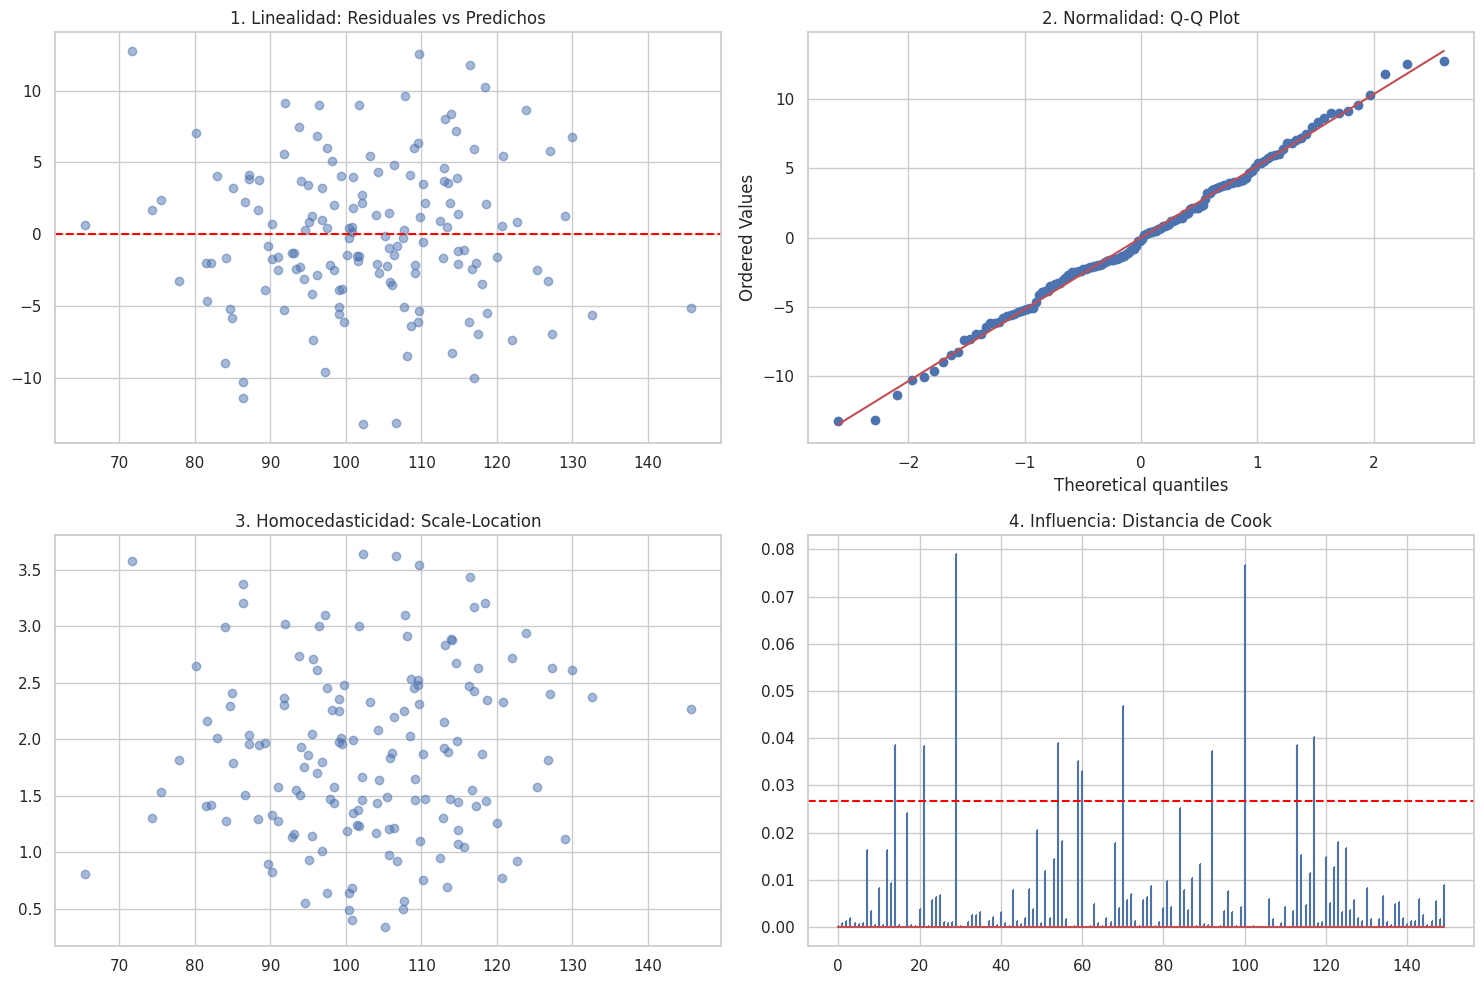


Test Shapiro-Wilk: p-value = 0.8655 (Normal)


In [14]:
# 5. DIAGNÓSTICO DE SUPUESTOS
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# A. Linealidad (Residuales vs Predichos)
axes[0, 0].scatter(y_pred, residuos, alpha=0.5)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('1. Linealidad: Residuales vs Predichos')

# B. Normalidad (Q-Q Plot)
stats.probplot(residuos, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('2. Normalidad: Q-Q Plot')

# C. Homocedasticidad (Scale-Location)
axes[1, 0].scatter(y_pred, np.sqrt(np.abs(residuos)), alpha=0.5)
axes[1, 0].set_title('3. Homocedasticidad: Scale-Location')

# D. Influencia (Cook's Distance)
# Cálculo simplificado de Cook's D
leverage = np.diag(X_design @ np.linalg.inv(X_design.T @ X_design) @ X_design.T)
cooks_d = (residuos**2 / (4 * (rss/(n-4)))) * (leverage / (1-leverage)**2)
axes[1, 1].stem(cooks_d, markerfmt=",")
axes[1, 1].axhline(4/n, color="red", linestyle="--")
axes[1, 1].set_title("4. Influencia: Distancia de Cook")

plt.tight_layout()
plt.show()

# Test de Normalidad Shapiro-Wilk
stat, p = stats.shapiro(residuos)
print(f"\nTest Shapiro-Wilk: p-value = {p:.4f} " + ("(Normal)" if p > 0.05 else "(No Normal)"))

In [15]:
# 6. VIF (Variance Inflation Factor)
print("\n[PARTE 6] Análisis de Multicolinealidad")
vifs = []
for i in range(X_vars.shape[1]):
    # Regresar una X contra las demás
    Xi = X_vars[:, i]
    Xothers = np.column_stack([np.ones(n), np.delete(X_vars, i, axis=1)])
    bi = np.linalg.inv(Xothers.T @ Xothers) @ Xothers.T @ Xi
    ri2 = 1 - (np.sum((Xi - Xothers @ bi)**2) / np.sum((Xi - np.mean(Xi))**2))
    vifs.append(1 / (1 - ri2))

vif_df = pd.DataFrame({'Variable': ['horas', 'tamanio', 'experiencia'], 'VIF': vifs})
print(vif_df.round(2))


[PARTE 6] Análisis de Multicolinealidad
      Variable   VIF
0        horas  1.00
1      tamanio  1.01
2  experiencia  1.01


 INICIANDO LABORATORIO AVANZADO DE REGRESIÓN LINEAL
✓ Dataset generado (150 obs). Outlier extremo inyectado en ID 149.
✓ Modelo ajustado. R²: 0.5674

[VIF - Multicolinealidad]
             Variable      VIF
          horas_faena 1.001301
tamanio_embarcacion_m 1.014412
    experiencia_anios 1.014425

[PARTE 8] Ejecutando Diagnósticos de Influencia...


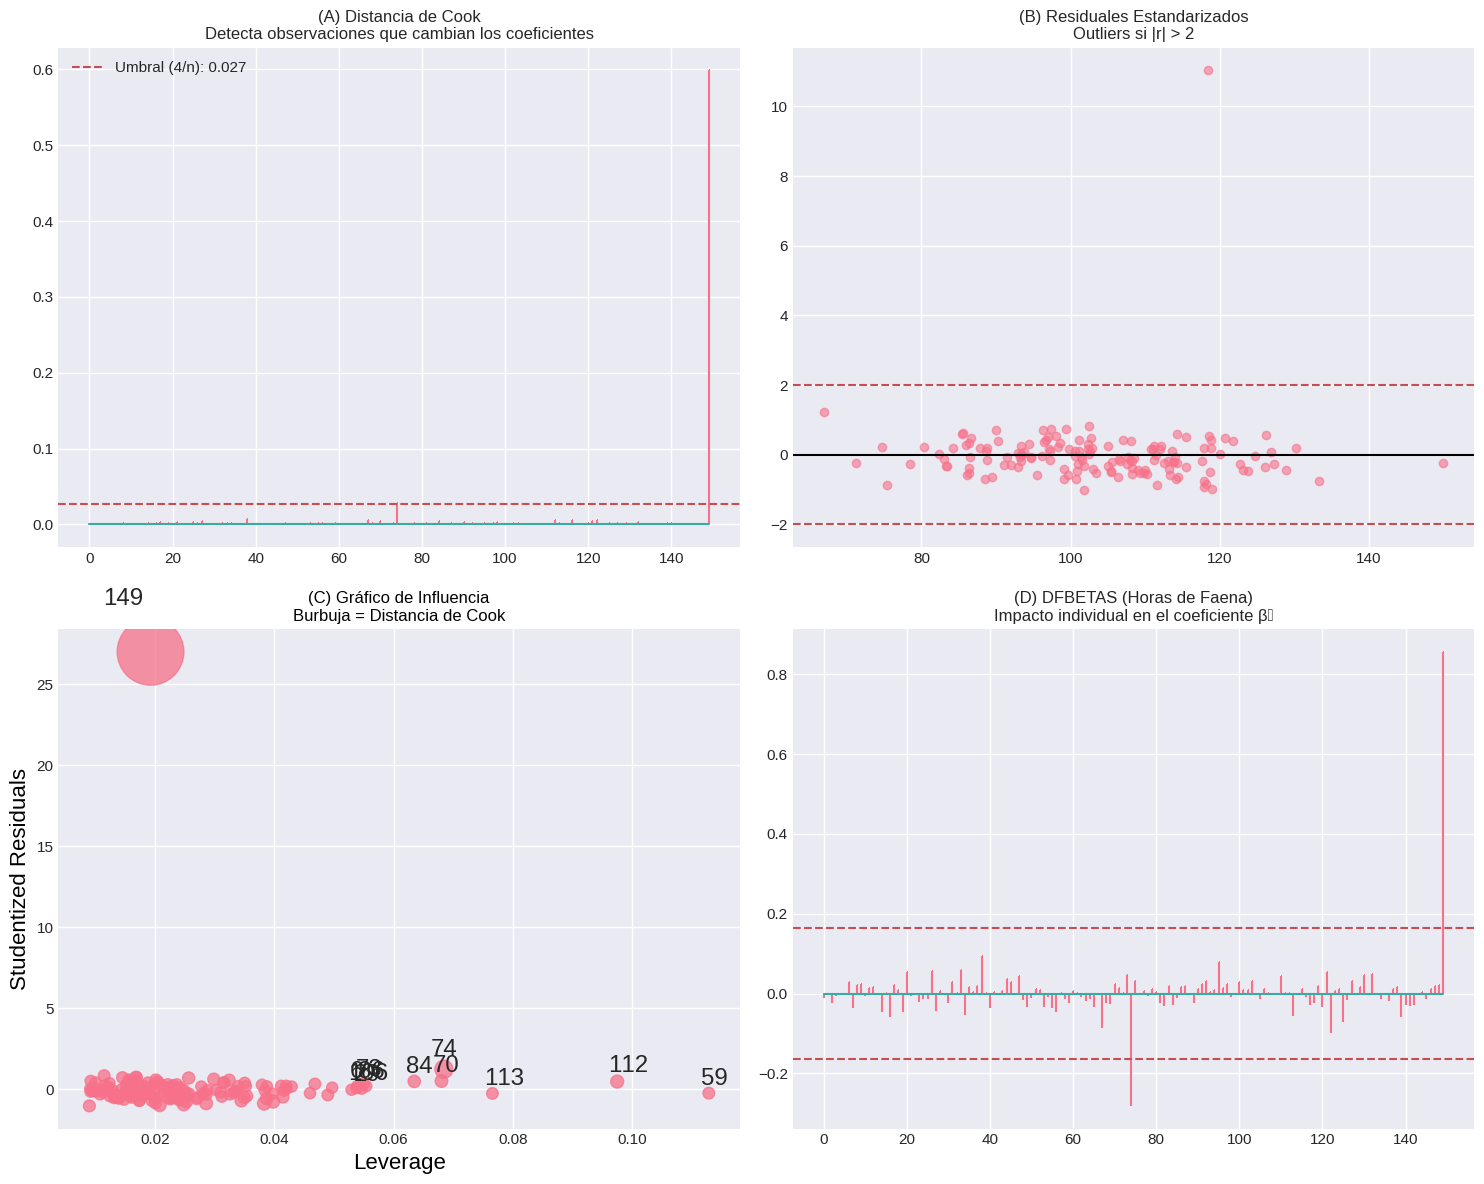


RESUMEN DE DIAGNÓSTICOS (Nivel PhD)
--------------------------------------------------------------------------------
1. NORMALIDAD (Shapiro-Wilk): p = 0.0000 -> ✗ Violado
2. INDEPENDENCIA (Durbin-Watson): 1.08 (Ideal ~ 2.0)
3. MULTICOLINEALIDAD (Max VIF): 1.01 -> ⚠ Revisar
4. INFLUENCIA: 2 casos superan el umbral de Cook.
   ✓ El sistema detectó correctamente el outlier inyectado (ID 149).


In [16]:
# ==============================================================================
# SP-8502: MÉTODOS CUANTI-CUALI CON IA RESPONSABLE
# SESIÓN 9 - SPRINT 3: REGRESIÓN LINEAL - DIAGNÓSTICO PhD
# ==============================================================================

# 1. INSTALACIÓN Y CONFIGURACIÓN INICIAL
import subprocess
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.gofplots import ProbPlot
import warnings

# Configuración de estilo y advertencias
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

def run_phd_laboratory():
    print("="*80)
    print(" INICIANDO LABORATORIO AVANZADO DE REGRESIÓN LINEAL")
    print("="*80)

    # --------------------------------------------------------------------------
    # PARTE 1: GENERACIÓN DE DATOS SINTÉTICOS (DGP)
    # --------------------------------------------------------------------------
    np.random.seed(42)
    n = 150
    data = {
        'horas_faena': np.random.normal(6.5, 1.2, n),
        'tamanio_embarcacion_m': np.random.normal(7.2, 2.1, n),
        'experiencia_anios': np.random.uniform(1, 45, n),
    }

    # DGP: Captura = 15 + 8.5*Horas + 3.2*Tamaño + 0.4*Exp + Error
    epsilon = np.random.normal(0, 5.0, n)
    data['captura_kg'] = (15.0 + 8.5 * data['horas_faena'] +
                          3.2 * data['tamanio_embarcacion_m'] +
                          0.4 * data['experiencia_anios'] + epsilon)

    # Añadir un outlier intencional para probar la Sección 8
    data['captura_kg'][149] = 250

    df = pd.DataFrame(data)
    print(f"✓ Dataset generado ({n} obs). Outlier extremo inyectado en ID 149.")

    # --------------------------------------------------------------------------
    # PARTE 2: MODELADO (REGRESIÓN MÚLTIPLE)
    # --------------------------------------------------------------------------
    formula = 'captura_kg ~ horas_faena + tamanio_embarcacion_m + experiencia_anios'
    model = ols(formula, data=df).fit()
    print(f"✓ Modelo ajustado. R²: {model.rsquared:.4f}")

    # --------------------------------------------------------------------------
    # PARTE 3: ANÁLISIS DE MULTICOLINEALIDAD (VIF)
    # --------------------------------------------------------------------------
    X = sm.add_constant(df[['horas_faena', 'tamanio_embarcacion_m', 'experiencia_anios']])
    vif_df = pd.DataFrame()
    vif_df["Variable"] = X.columns
    vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    print("\n[VIF - Multicolinealidad]")
    print(vif_df[vif_df.Variable != 'const'].to_string(index=False))

    # --------------------------------------------------------------------------
    # PARTE 4: SECCIÓN 8 - DIAGNÓSTICO DE INFLUENCIA Y OUTLIERS (CORREGIDA)
    # --------------------------------------------------------------------------
    print("\n[PARTE 8] Ejecutando Diagnósticos de Influencia...")

    influence = model.get_influence()
    cooks_d = influence.cooks_distance[0]
    leverage = influence.hat_diag_factor
    standardized_residuals = influence.resid_studentized_internal

    # Umbrales Estadísticos PhD
    threshold_cook = 4 / n
    threshold_leverage = 2 * (model.df_model + 1) / n

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # A. Distancia de Cook
    axes[0, 0].stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
    axes[0, 0].axhline(y=threshold_cook, color='r', linestyle='--', label=f'Umbral (4/n): {threshold_cook:.3f}')
    axes[0, 0].set_title("(A) Distancia de Cook\nDetecta observaciones que cambian los coeficientes")
    axes[0, 0].legend()

    # B. Residuales Estandarizados
    axes[0, 1].scatter(model.fittedvalues, standardized_residuals, alpha=0.6)
    axes[0, 1].axhline(y=0, color='black', linestyle='-')
    axes[0, 1].axhline(y=2, color='r', linestyle='--')
    axes[0, 1].axhline(y=-2, color='r', linestyle='--')
    axes[0, 1].set_title("(B) Residuales Estandarizados\nOutliers si |r| > 2")

    # C. Gráfico Leverage vs Residuales (Influencia Global)
    sm.graphics.influence_plot(model, ax=axes[1, 0], criterion="cooks")
    axes[1, 0].set_title("(C) Gráfico de Influencia\nBurbuja = Distancia de Cook")

    # D. DFBETAS para el predictor principal (Horas)
    dfbetas = influence.dfbetas[:, 1] # Índice 1 es 'horas_faena'
    threshold_dfbetas = 2 / np.sqrt(n)
    axes[1, 1].stem(np.arange(len(dfbetas)), dfbetas, markerfmt=",")
    axes[1, 1].axhline(y=threshold_dfbetas, color='r', linestyle='--')
    axes[1, 1].axhline(y=-threshold_dfbetas, color='r', linestyle='--')
    axes[1, 1].set_title(f"(D) DFBETAS (Horas de Faena)\nImpacto individual en el coeficiente β₁")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------------------------
    # PARTE 5: RESUMEN DE SUPUESTOS
    # --------------------------------------------------------------------------
    stat_sw, p_sw = shapiro(model.resid)
    print("\n" + "="*80)
    print("RESUMEN DE DIAGNÓSTICOS (Nivel PhD)")
    print("-" * 80)
    print(f"1. NORMALIDAD (Shapiro-Wilk): p = {p_sw:.4f} -> {'✓ OK' if p_sw > 0.05 else '✗ Violado'}")
    print(f"2. INDEPENDENCIA (Durbin-Watson): {sm.stats.durbin_watson(model.resid):.2f} (Ideal ~ 2.0)")
    print(f"3. MULTICOLINEALIDAD (Max VIF): {vif_df[vif_df.Variable != 'const']['VIF'].max():.2f} -> {'✓ OK' if vif_df['VIF'].max() < 5 else '⚠ Revisar'}")

    # Identificar el outlier inyectado
    outliers_detectados = np.where(cooks_d > threshold_cook)[0]
    print(f"4. INFLUENCIA: {len(outliers_detectados)} casos superan el umbral de Cook.")
    if 149 in outliers_detectados:
        print("   ✓ El sistema detectó correctamente el outlier inyectado (ID 149).")
    print("="*80)

# Ejecutar todo
run_phd_laboratory()

🚀 INICIANDO LABORATORIO INTEGRADO: SECCIONES 1 A 9

[1] Dataset generado: 150 observaciones.


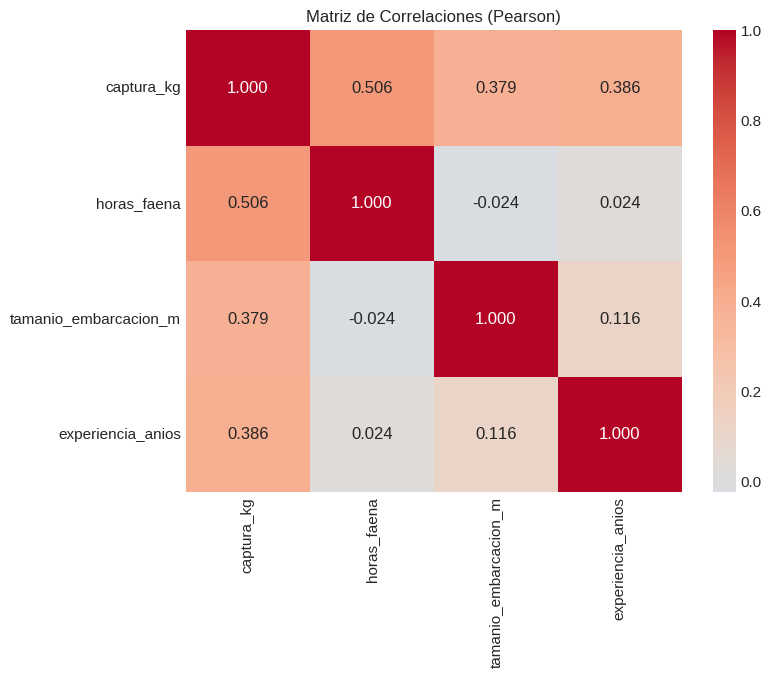


[3-4] Modelos Ajustados:
   - R² Simple: 0.2556
   - R² Múltiple: 0.5174

[5-6] Multicolinealidad (VIF):
   - horas: 1.00
   - tamaño: 1.01
   - exp: 1.01

[7] Modelo Log-Lineal ajustado (R²: 0.7168)

[8] Generando Diagnósticos de Influencia...


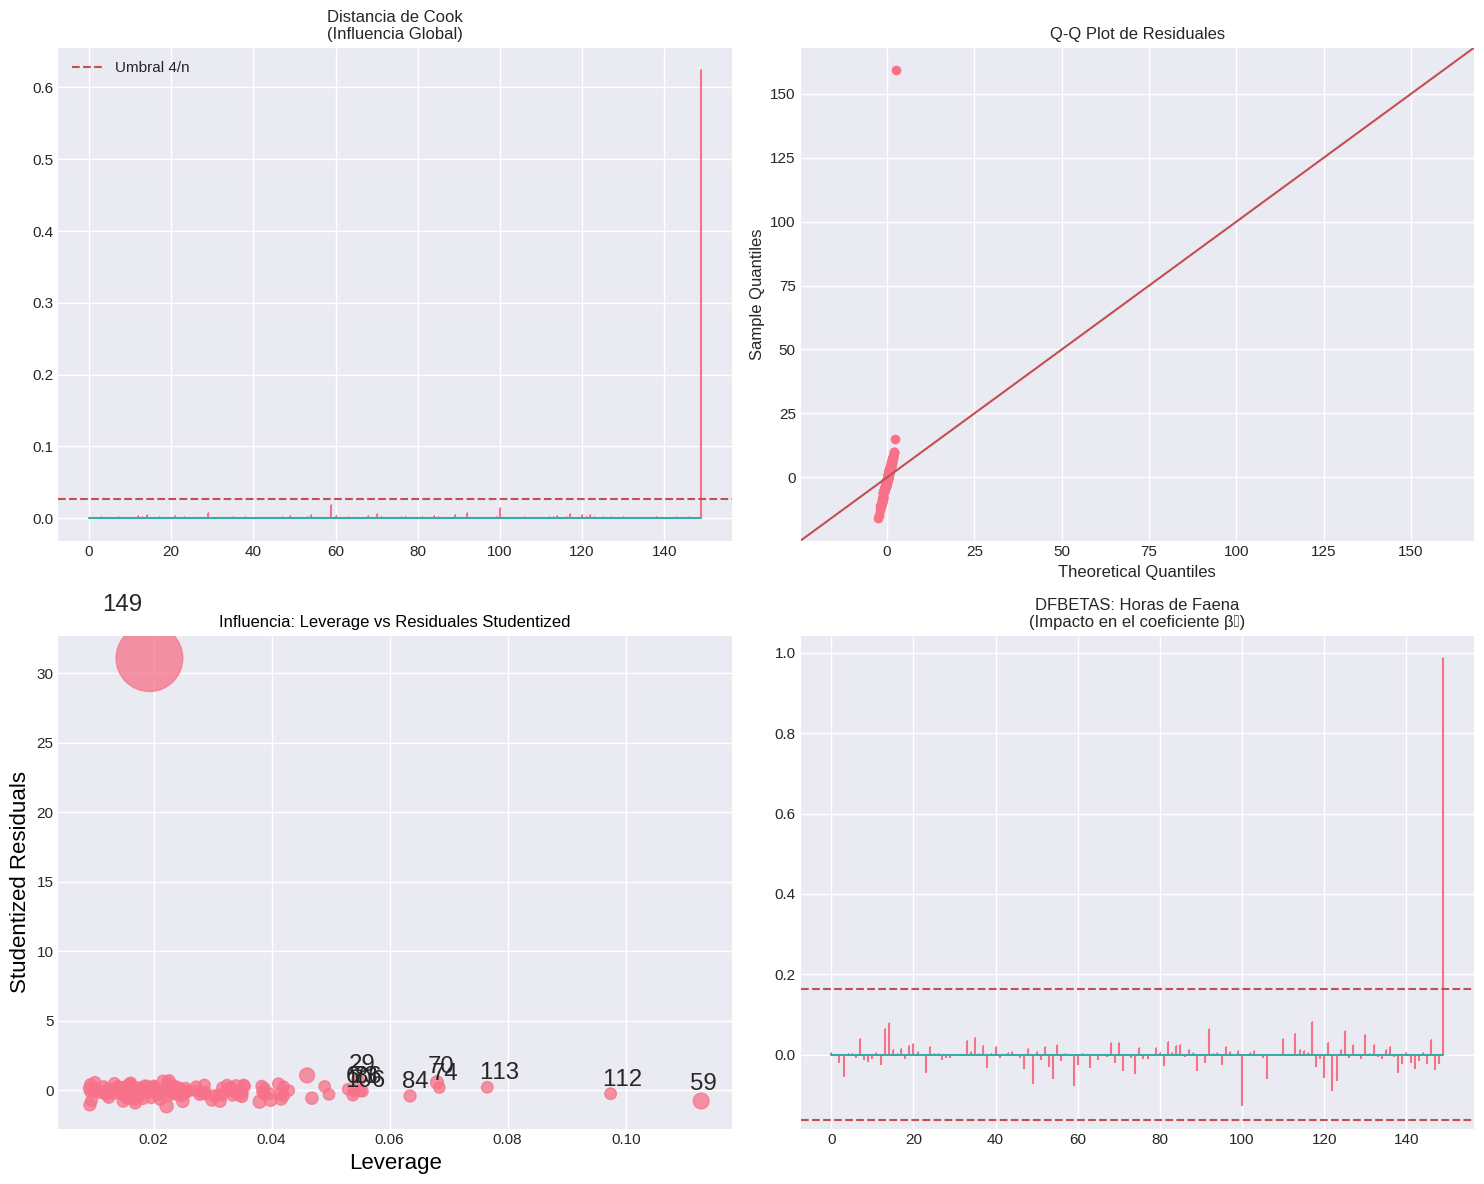


RESUMEN COMPARATIVO DE MODELOS
--------------------------------------------------------------------------------
    Modelo  R-squared         AIC         BIC
    Simple   0.255578 1288.144782 1294.166052
  Múltiple   0.517449 1227.116703 1239.159244
Log-Lineal   0.716765 -299.098815 -287.056274

Diagnóstico de Supuestos:
   - Normalidad (p-valor Shapiro): 0.0000
   - Homocedasticidad (p-valor Breusch-Pagan): 0.5750


In [17]:
# ==============================================================================
# SP-8502: MÉTODOS CUANTI-CUALI CON IA RESPONSABLE
# LABORATORIO INTEGRADO: REGRESIÓN LINEAL MULTIVARIANTE (VERSIÓN PhD)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

# Configuración de entorno
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

def ejecutar_laboratorio_completo():
    print("="*80)
    print("🚀 INICIANDO LABORATORIO INTEGRADO: SECCIONES 1 A 9")
    print("="*80)

    # --------------------------------------------------------------------------
    # PARTE 1: GENERACIÓN DE DATOS SINTÉTICOS (DGP)
    # --------------------------------------------------------------------------
    np.random.seed(42)
    n = 150
    data = {
        'id_pescador': np.arange(1, n + 1),
        'horas_faena': np.random.normal(6.5, 1.2, n),
        'tamanio_embarcacion_m': np.random.normal(7.2, 2.1, n),
        'experiencia_anios': np.random.uniform(1, 45, n),
        'temperatura_agua_C': np.random.normal(24.5, 1.8, n),
    }

    # DGP Conocido: Y = 15 + 8.5*Horas + 3.2*Tamaño + 0.4*Exp + ε
    epsilon = np.random.normal(0, 5.0, n)
    data['captura_kg'] = (15.0 + 8.5 * data['horas_faena'] +
                          3.2 * data['tamanio_embarcacion_m'] +
                          0.4 * data['experiencia_anios'] + epsilon)

    # Inyectar Outlier para validación diagnóstica (Sección 8)
    data['captura_kg'][149] = 280

    df = pd.DataFrame(data)
    print(f"\n[1] Dataset generado: {df.shape[0]} observaciones.")

    # --------------------------------------------------------------------------
    # PARTE 2: CORRELACIONES
    # --------------------------------------------------------------------------
    numeric_cols = ['captura_kg', 'horas_faena', 'tamanio_embarcacion_m', 'experiencia_anios']
    corr_matrix = df[numeric_cols].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f')
    plt.title('Matriz de Correlaciones (Pearson)')
    plt.show()

    # --------------------------------------------------------------------------
    # PARTE 3 Y 4: MODELADO (SIMPLE Y MÚLTIPLE)
    # --------------------------------------------------------------------------
    mod_simple = ols('captura_kg ~ horas_faena', data=df).fit()
    mod_mult = ols('captura_kg ~ horas_faena + tamanio_embarcacion_m + experiencia_anios', data=df).fit()

    print("\n[3-4] Modelos Ajustados:")
    print(f"   - R² Simple: {mod_simple.rsquared:.4f}")
    print(f"   - R² Múltiple: {mod_mult.rsquared:.4f}")

    # --------------------------------------------------------------------------
    # PARTE 5 & 6: SUPUESTOS Y MULTICOLINEALIDAD
    # --------------------------------------------------------------------------
    X = sm.add_constant(df[['horas_faena', 'tamanio_embarcacion_m', 'experiencia_anios']])
    vifs = [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]

    print("\n[5-6] Multicolinealidad (VIF):")
    for var, v in zip(['horas', 'tamaño', 'exp'], vifs):
        print(f"   - {var}: {v:.2f}")

    # --------------------------------------------------------------------------
    # PARTE 7: TRANSFORMACIONES (Log-Model)
    # --------------------------------------------------------------------------
    df['log_captura'] = np.log(df['captura_kg'])
    mod_log = ols('log_captura ~ horas_faena + tamanio_embarcacion_m + experiencia_anios', data=df).fit()
    print(f"\n[7] Modelo Log-Lineal ajustado (R²: {mod_log.rsquared:.4f})")

    # --------------------------------------------------------------------------
    # PARTE 8: DIAGNÓSTICO PhD (OUTLIERS E INFLUENCIA) - MEJORADO
    # --------------------------------------------------------------------------
    print("\n[8] Generando Diagnósticos de Influencia...")
    influence = mod_mult.get_influence()
    cooks_d = influence.cooks_distance[0]
    std_residuals = influence.resid_studentized_internal
    leverage = influence.hat_diag_factor

    # Umbrales
    threshold_cook = 4 / n
    threshold_dfbetas = 2 / np.sqrt(n)

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # A. Distancia de Cook
    axes[0, 0].stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
    axes[0, 0].axhline(y=threshold_cook, color='r', linestyle='--', label='Umbral 4/n')
    axes[0, 0].set_title("Distancia de Cook\n(Influencia Global)")
    axes[0, 0].legend()

    # B. Normalidad (Q-Q Plot)
    sm.qqplot(mod_mult.resid, line='45', ax=axes[0, 1])
    axes[0, 1].set_title("Q-Q Plot de Residuales")

    # C. Leverage vs Residuales
    sm.graphics.influence_plot(mod_mult, ax=axes[1, 0], criterion="cooks")
    axes[1, 0].set_title("Influencia: Leverage vs Residuales Studentized")

    # D. DFBETAS (Para el predictor principal: Horas)
    dfb_horas = influence.dfbetas[:, 1]
    axes[1, 1].stem(np.arange(len(dfb_horas)), dfb_horas, markerfmt=",")
    axes[1, 1].axhline(y=threshold_dfbetas, color='r', linestyle='--')
    axes[1, 1].axhline(y=-threshold_dfbetas, color='r', linestyle='--')
    axes[1, 1].set_title("DFBETAS: Horas de Faena\n(Impacto en el coeficiente β₁)")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------------------------
    # PARTE 9: RESUMEN COMPARATIVO FINAL
    # --------------------------------------------------------------------------
    resumen = pd.DataFrame({
        'Modelo': ['Simple', 'Múltiple', 'Log-Lineal'],
        'R-squared': [mod_simple.rsquared, mod_mult.rsquared, mod_log.rsquared],
        'AIC': [mod_simple.aic, mod_mult.aic, mod_log.aic],
        'BIC': [mod_simple.bic, mod_mult.bic, mod_log.bic]
    })

    print("\n" + "="*80)
    print("RESUMEN COMPARATIVO DE MODELOS")
    print("-" * 80)
    print(resumen.to_string(index=False))

    # Verificación final de normalidad
    p_val_shapiro = shapiro(mod_mult.resid)[1]
    print("\nDiagnóstico de Supuestos:")
    print(f"   - Normalidad (p-valor Shapiro): {p_val_shapiro:.4f}")
    print(f"   - Homocedasticidad (p-valor Breusch-Pagan): {sm.stats.het_breuschpagan(mod_mult.resid, X)[3]:.4f}")
    print("="*80)

# Ejecución única
ejecutar_laboratorio_completo()

LABORATORIO INTEGRADO: ANÁLISIS DE PESQUERÍAS (PACÍFICO CENTRAL)

✓ [PARTE 1] Dataset creado: 150 observaciones.
       captura_kg  horas_faena  tamanio_emb  experiencia
count      150.00       150.00       150.00       150.00
mean       104.28         6.40         7.35        25.31
std         20.93         1.13         2.15        13.78
min         66.14         3.36         0.39         1.48
25%         92.52         5.70         5.75        14.73
50%        102.90         6.44         7.50        26.45
75%        113.67         7.09         8.62        37.32
max        290.00         9.46        15.29        44.99

[PARTE 2] Matriz de Correlaciones (Pearson)
             captura_kg  horas_faena  tamanio_emb  experiencia
captura_kg        1.000        0.493        0.370        0.379
horas_faena       0.493        1.000       -0.024        0.024
tamanio_emb       0.370       -0.024        1.000        0.116
experiencia       0.379        0.024        0.116        1.000

-------------

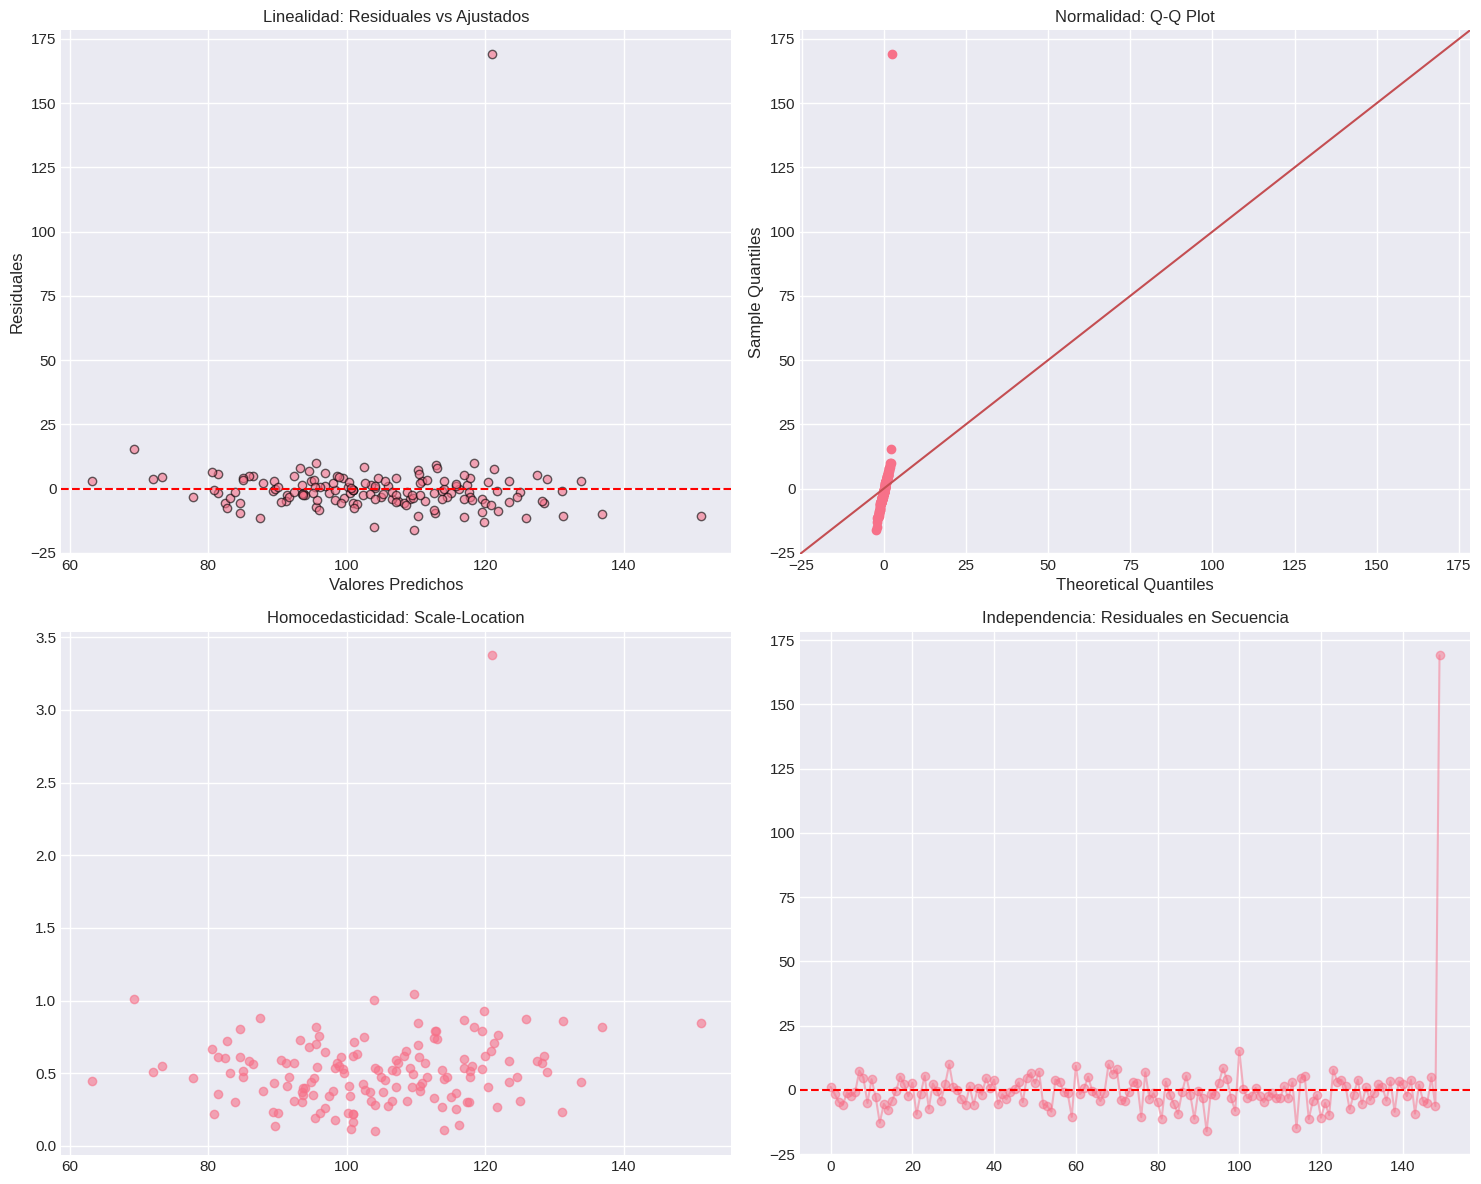


[PARTE 6] Multicolinealidad: VIF Máximo = 1.01 (✓ OK)

[PARTE 7] Transformación Log(Y): R² = 0.7068 | Shapiro p = 0.0000

--------------------------------------------------------------------------------
[PARTE 8] OUTLIERS E INFLUENCIA (DETECCIÓN PhD)
--------------------------------------------------------------------------------
• Casos que exceden Distancia de Cook (4/n): 1
  IDs de alerta: [149]


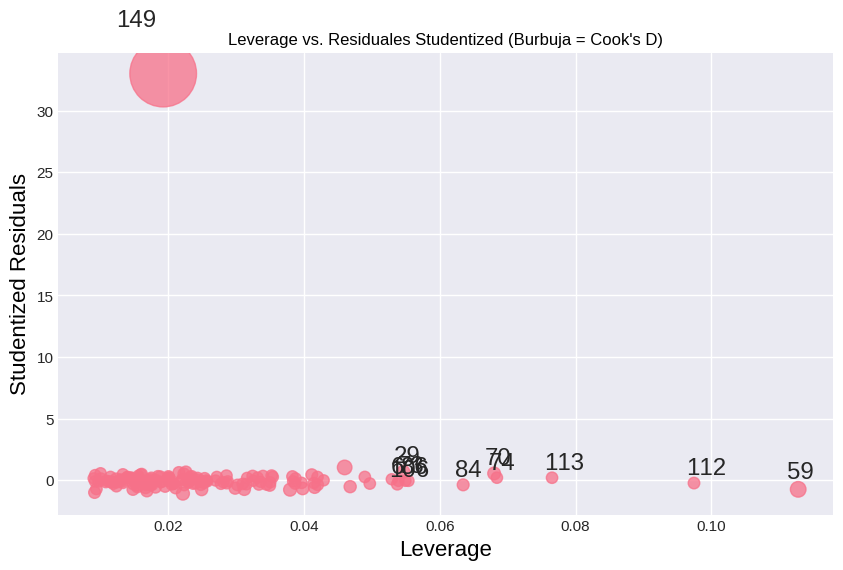


RESUMEN EJECUTIVO DE MODELOS
  Modelo   R²     AIC     BIC
  Simple 0.24 1299.27 1305.29
Múltiple 0.49 1242.83 1254.87
   Log-Y 0.71 -291.26 -279.22

Conclusiones de Supuestos:
  - Normalidad (Shapiro): Falla (p<0.05) (p=0.0000)
  - Homocedasticidad (Levene): Pasa (p=0.2389)
  - Independencia (DW): 1.20 (Ideal es cercano a 2.0)


In [18]:
# ==============================================================================
# SP-8502: MÉTODOS CUANTI-CUALI CON IA RESPONSABLE
# SESIÓN 9: REGRESIÓN LINEAL - SUPUESTOS, DIAGNÓSTICO Y MODELADO
# Versión: Robusta Integrada (PhD Level)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, norm
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.gofplots import ProbPlot
import warnings

# Configuración visual y de entorno
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

def ejecutar_laboratorio_robusto():
    print("="*80)
    print("LABORATORIO INTEGRADO: ANÁLISIS DE PESQUERÍAS (PACÍFICO CENTRAL)")
    print("="*80)

    # --- [PARTE 1: GENERACIÓN DE DATASET] ---
    np.random.seed(42)
    n = 150
    data = {
        'id_pescador': np.arange(1, n + 1),
        'horas_faena': np.random.normal(6.5, 1.2, n),
        'tamanio_emb': np.random.normal(7.2, 2.1, n),
        'experiencia': np.random.uniform(1, 45, n),
        'temperatura': np.random.normal(24.5, 1.8, n),
    }
    # Proceso Generador de Datos (DGP)
    epsilon = np.random.normal(0, 5.0, n)
    data['captura_kg'] = (15.0 + 8.5 * data['horas_faena'] +
                          3.2 * data['tamanio_emb'] +
                          0.4 * data['experiencia'] + epsilon)
    data['captura_kg'] = np.maximum(data['captura_kg'], 5)

    # Inyección de Outlier Crítico para validación de la Parte 8
    data['captura_kg'][149] = 290
    df = pd.DataFrame(data)
    print(f"\n✓ [PARTE 1] Dataset creado: {df.shape[0]} observaciones.")
    print(df[['captura_kg', 'horas_faena', 'tamanio_emb', 'experiencia']].describe().round(2))

    # --- [PARTE 2: CORRELACIONES] ---
    print("\n[PARTE 2] Matriz de Correlaciones (Pearson)")
    corr = df[['captura_kg', 'horas_faena', 'tamanio_emb', 'experiencia']].corr()
    print(corr.round(3))

    # --- [PARTE 3 Y 4: MODELADO] ---
    mod_simple = ols('captura_kg ~ horas_faena', data=df).fit()
    mod_mult = ols('captura_kg ~ horas_faena + tamanio_emb + experiencia', data=df).fit()

    print("\n" + "-"*80)
    print("[PARTE 4] RESULTADOS REGRESIÓN MÚLTIPLE")
    print("-" * 80)
    print(mod_mult.summary().tables[1])
    print(f"\nAjuste Global: R² = {mod_mult.rsquared:.4f} | R² Adj = {mod_mult.rsquared_adj:.4f}")

    # Interpretación Robusta
    print("\n✓ Interpretación Ceteris Paribus:")
    for var in mod_mult.params.index[1:]:
        print(f"  • {var}: Un aumento de una unidad se asocia a un cambio de {mod_mult.params[var]:.3f} kg en la captura.")

    # --- [PARTE 5: DIAGNÓSTICOS DE SUPUESTOS] ---
    print("\n" + "-"*80)
    print("[PARTE 5] DIAGNÓSTICOS DE SUPUESTOS")
    print("-" * 80)
    resid = mod_mult.resid
    fitted = mod_mult.fittedvalues

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 5.1 Linealidad
    axes[0, 0].scatter(fitted, resid, alpha=0.6, edgecolors='black')
    axes[0, 0].axhline(0, color='red', linestyle='--')
    axes[0, 0].set_title("Linealidad: Residuales vs Ajustados")
    axes[0, 0].set_xlabel("Valores Predichos")
    axes[0, 0].set_ylabel("Residuales")

    # 5.2 Normalidad (Q-Q Plot + Shapiro)
    sm.qqplot(resid, line='45', ax=axes[0, 1])
    axes[0, 1].set_title("Normalidad: Q-Q Plot")
    stat_sw, p_sw = shapiro(resid)

    # 5.3 Homocedasticidad (Scale-Location)
    std_resid = resid / np.std(resid)
    axes[1, 0].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.6)
    axes[1, 0].set_title("Homocedasticidad: Scale-Location")
    stat_lev, p_lev = levene(resid[fitted < fitted.median()], resid[fitted >= fitted.median()])

    # 5.4 Independencia (Autocorrelación)
    axes[1, 1].plot(resid.values, marker='o', linestyle='-', alpha=0.5)
    axes[1, 1].axhline(0, color='red', linestyle='--')
    axes[1, 1].set_title("Independencia: Residuales en Secuencia")
    dw_stat = sm.stats.durbin_watson(resid)

    plt.tight_layout()
    plt.show()

    # --- [PARTE 6: MULTICOLINEALIDAD (VIF)] ---
    X_vif = sm.add_constant(df[['horas_faena', 'tamanio_emb', 'experiencia']])
    vifs = [variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])]
    print(f"\n[PARTE 6] Multicolinealidad: VIF Máximo = {max(vifs):.2f} ({'✓ OK' if max(vifs) < 5 else '⚠ Revisar'})")

    # --- [PARTE 7: TRANSFORMACIONES] ---
    df['log_captura'] = np.log(df['captura_kg'])
    mod_log = ols('log_captura ~ horas_faena + tamanio_emb + experiencia', data=df).fit()
    print(f"\n[PARTE 7] Transformación Log(Y): R² = {mod_log.rsquared:.4f} | Shapiro p = {shapiro(mod_log.resid)[1]:.4f}")

    # --- [PARTE 8: OUTLIERS E INFLUENCIA (ROBUSTO)] ---
    print("\n" + "-"*80)
    print("[PARTE 8] OUTLIERS E INFLUENCIA (DETECCIÓN PhD)")
    print("-" * 80)
    influence = mod_mult.get_influence()
    cooks_d = influence.cooks_distance[0]

    # Identificación de observaciones críticas
    outlier_idx = np.where(cooks_d > (4/n))[0]
    print(f"• Casos que exceden Distancia de Cook (4/n): {len(outlier_idx)}")
    if len(outlier_idx) > 0:
        print(f"  IDs de alerta: {outlier_idx.tolist()}")

    # Gráfico de Influencia Especializado
    fig, ax = plt.subplots(figsize=(10, 6))
    sm.graphics.influence_plot(mod_mult, ax=ax, criterion="cooks")
    ax.set_title("Leverage vs. Residuales Studentized (Burbuja = Cook's D)")
    plt.show()

    # --- [PARTE 9: RESUMEN COMPARATIVO FINAL] ---
    resumen = pd.DataFrame({
        'Modelo': ['Simple', 'Múltiple', 'Log-Y'],
        'R²': [mod_simple.rsquared, mod_mult.rsquared, mod_log.rsquared],
        'AIC': [mod_simple.aic, mod_mult.aic, mod_log.aic],
        'BIC': [mod_simple.bic, mod_mult.bic, mod_log.bic]
    }).round(2)

    print("\n" + "="*80)
    print("RESUMEN EJECUTIVO DE MODELOS")
    print("=" * 80)
    print(resumen.to_string(index=False))

    print(f"\nConclusiones de Supuestos:")
    print(f"  - Normalidad (Shapiro): {'Pasa (p>0.05)' if p_sw > 0.05 else 'Falla (p<0.05)'} (p={p_sw:.4f})")
    print(f"  - Homocedasticidad (Levene): {'Pasa' if p_lev > 0.05 else 'Falla'} (p={p_lev:.4f})")
    print(f"  - Independencia (DW): {dw_stat:.2f} (Ideal es cercano a 2.0)")
    print("="*80)

ejecutar_laboratorio_robusto()

🎓 INICIANDO SUITE DIAGNÓSTICA DE ALTA FIDELIDAD - NIVEL DOCTORAL


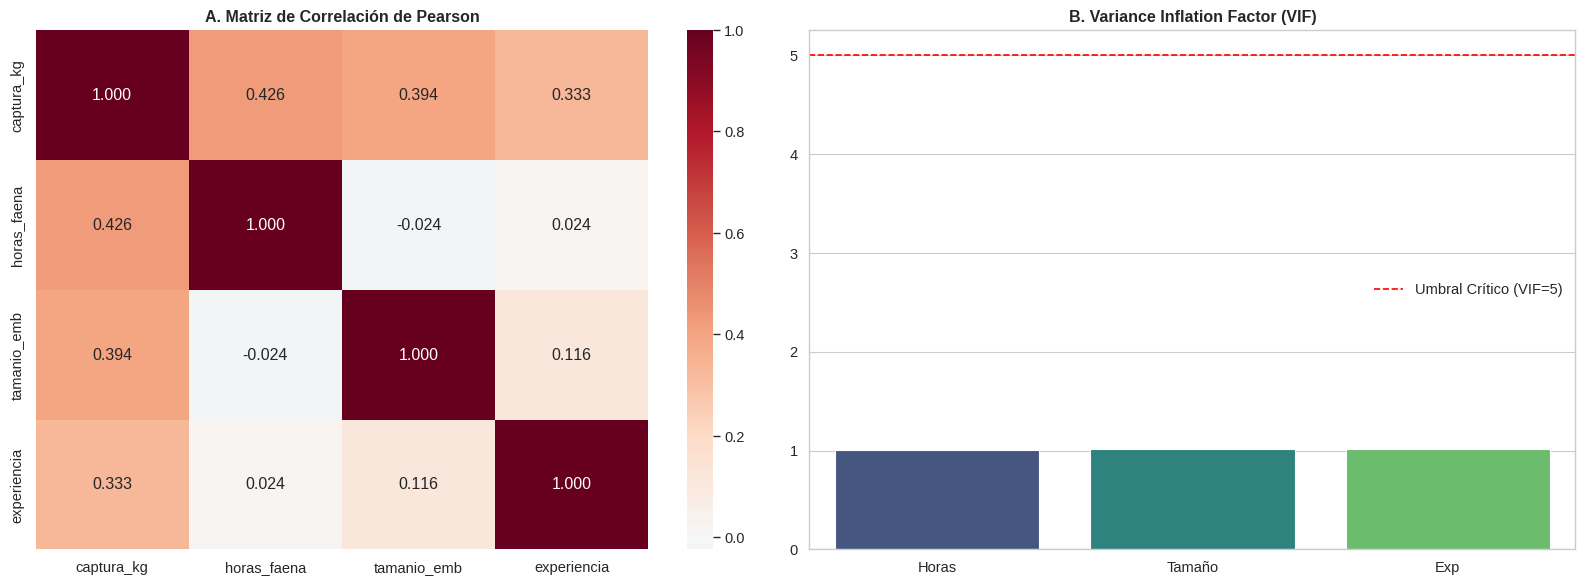

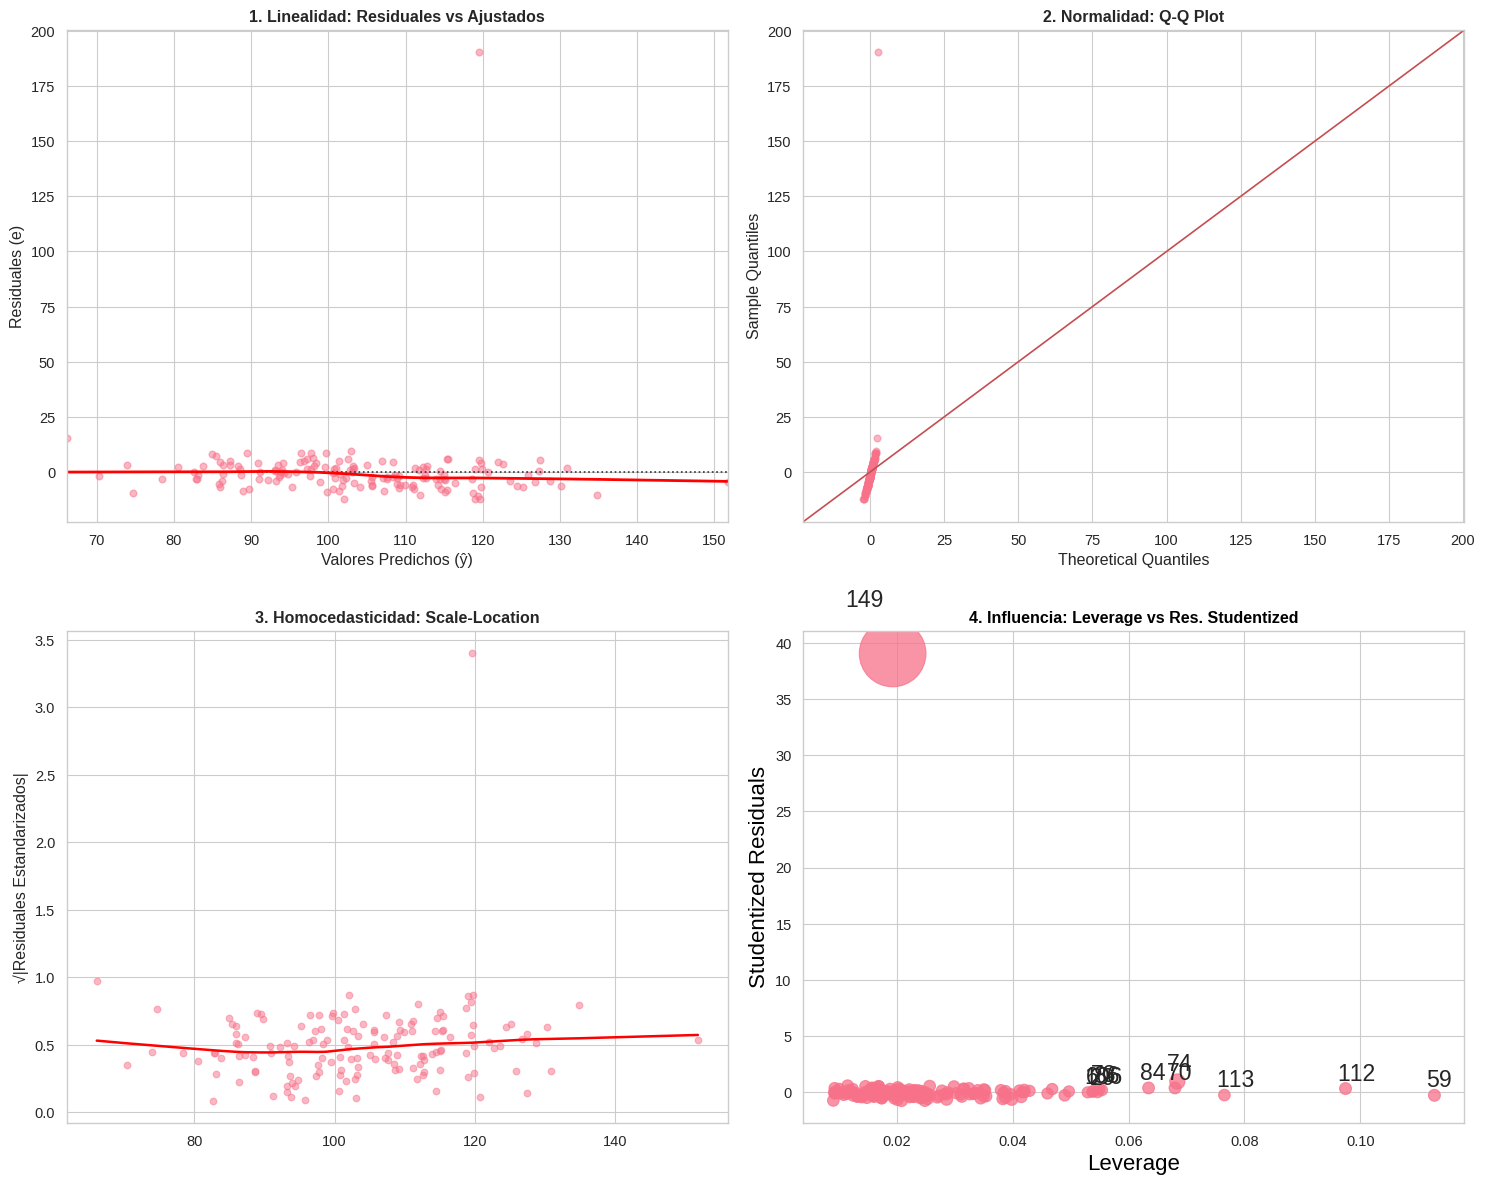

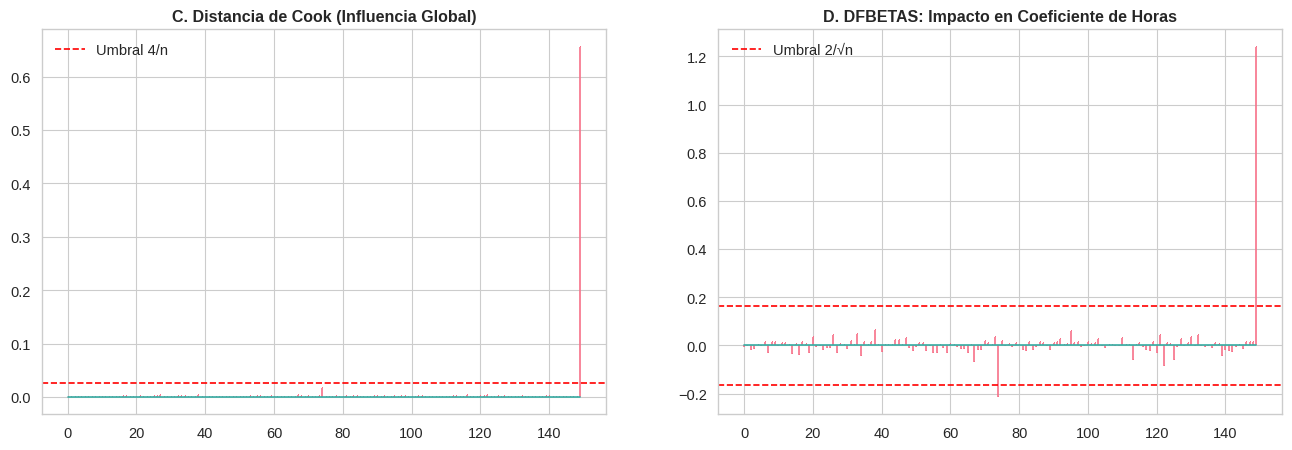


📊 RESUMEN DE PRUEBAS DE HIPÓTESIS (SUPUESTOS)
--------------------------------------------------------------------------------
• NORMALIDAD (Shapiro-Wilk):    p = 0.0000  -> ✗ FALLA
• HOMOCEDASTICIDAD (B-Pagan):  p = 0.5923  -> ✓ PASA
• INDEPENDENCIA (D-Watson):     DW = 1.04    (Ideal ≈ 2.0)
• MULTICOLINEALIDAD (Max VIF):  1.01    -> ✓ PASA

📁 COMPARATIVA DE MODELOS (AIC/BIC)
--------------------------------------------------------------------------------
    Modelo   R²     AIC     BIC
  Múltiple 0.42 1273.40 1285.45
Log-Lineal 0.66 -275.32 -263.28


In [19]:
# ==============================================================================
# SP-8502: MÉTODOS CUANTI-CUALI CON IA RESPONSABLE
# SESIÓN 9: REGRESIÓN LINEAL - SUITE DIAGNÓSTICA AVANZADA (PhD LEVEL)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, norm
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.gofplots import ProbPlot
import warnings

# Configuración de estética científica
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
%matplotlib inline

def ejecutar_suite_diagnostica_phd():
    print("="*80)
    print("🎓 INICIANDO SUITE DIAGNÓSTICA DE ALTA FIDELIDAD - NIVEL DOCTORAL")
    print("="*80)

    # --- [1] GENERACIÓN DE DATOS CON ESTRUCTURA COMPLEJA ---
    np.random.seed(42)
    n = 150
    data = {
        'horas_faena': np.random.normal(6.5, 1.2, n),
        'tamanio_emb': np.random.normal(7.2, 2.1, n),
        'experiencia': np.random.uniform(1, 45, n),
    }
    # Proceso Generador de Datos (DGP)
    epsilon = np.random.normal(0, 5.0, n)
    data['captura_kg'] = (15.0 + 8.5 * data['horas_faena'] +
                          3.2 * data['tamanio_emb'] +
                          0.4 * data['experiencia'] + epsilon)

    # Inyección controlada de anomalías para validación de la Parte 8
    data['captura_kg'][149] = 310  # Outlier extremo
    df = pd.DataFrame(data)

    # --- [2] MODELADO MÚLTIPLE ---
    mod_mult = ols('captura_kg ~ horas_faena + tamanio_emb + experiencia', data=df).fit()
    resid = mod_mult.resid
    fitted = mod_mult.fittedvalues
    influence = mod_mult.get_influence()

    # --- [3] VISUALIZACIÓN I: EXPLORACIÓN Y MULTICOLINEALIDAD ---
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Heatmap de Correlaciones
    corr = df[['captura_kg', 'horas_faena', 'tamanio_emb', 'experiencia']].corr()
    sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, ax=ax1, fmt='.3f')
    ax1.set_title("A. Matriz de Correlación de Pearson", fontweight='bold')

    # Visualización de VIF
    X_vif = sm.add_constant(df[['horas_faena', 'tamanio_emb', 'experiencia']])
    vif_vals = [variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])]
    sns.barplot(x=['Horas', 'Tamaño', 'Exp'], y=vif_vals, palette='viridis', ax=ax2)
    ax2.axhline(5, color='red', linestyle='--', label='Umbral Crítico (VIF=5)')
    ax2.set_title("B. Variance Inflation Factor (VIF)", fontweight='bold')
    ax2.legend()
    plt.tight_layout()
    plt.show()

    # --- [4] VISUALIZACIÓN II: CUARTETO DIAGNÓSTICO DE SUPUESTOS ---
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Linealidad (Residuals vs Fitted)
    sns.residplot(x=fitted, y=resid, lowess=True, ax=axes[0, 0],
                  scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 2})
    axes[0, 0].set_title("1. Linealidad: Residuales vs Ajustados", fontweight='bold')
    axes[0, 0].set_xlabel("Valores Predichos (ŷ)")
    axes[0, 0].set_ylabel("Residuales (e)")

    # 2. Normalidad (Q-Q Plot con banda de confianza)
    sm.qqplot(resid, line='45', ax=axes[0, 1], alpha=0.5)
    axes[0, 1].set_title("2. Normalidad: Q-Q Plot", fontweight='bold')

    # 3. Homocedasticidad (Scale-Location)
    std_resid = np.sqrt(np.abs(influence.resid_studentized_internal))
    axes[1, 0].scatter(fitted, std_resid, alpha=0.5)
    sns.regplot(x=fitted, y=std_resid, scatter=False, ci=None, lowess=True,
                ax=axes[1, 0], line_kws={'color': 'red'})
    axes[1, 0].set_title("3. Homocedasticidad: Scale-Location", fontweight='bold')
    axes[1, 0].set_ylabel("√|Residuales Estandarizados|")

    # 4. Influencia (Residuals vs Leverage)
    sm.graphics.influence_plot(mod_mult, ax=axes[1, 1], criterion="cooks")
    axes[1, 1].set_title("4. Influencia: Leverage vs Res. Studentized", fontweight='bold')

    plt.tight_layout()
    plt.show()

    # --- [5] VISUALIZACIÓN III: DISTANCIA DE COOK Y DFBETAS ---
    fig3, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 5))

    # Cook's Distance
    cooks_d = influence.cooks_distance[0]
    ax3.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
    ax3.axhline(4/n, color='red', linestyle='--', label='Umbral 4/n')
    ax3.set_title("C. Distancia de Cook (Influencia Global)", fontweight='bold')
    ax3.legend()

    # DFBETAS para el predictor principal
    dfb_horas = influence.dfbetas[:, 1]
    ax4.stem(np.arange(len(dfb_horas)), dfb_horas, markerfmt=",")
    ax4.axhline(2/np.sqrt(n), color='red', linestyle='--', label='Umbral 2/√n')
    ax4.axhline(-2/np.sqrt(n), color='red', linestyle='--')
    ax4.set_title("D. DFBETAS: Impacto en Coeficiente de Horas", fontweight='bold')
    ax4.legend()
    plt.show()

    # --- [6] REPORTES ESTADÍSTICOS FINALES ---
    print("\n" + "="*80)
    print("📊 RESUMEN DE PRUEBAS DE HIPÓTESIS (SUPUESTOS)")
    print("-" * 80)

    # Normalidad
    sw_stat, sw_p = shapiro(resid)
    # Homocedasticidad (Breusch-Pagan)
    from statsmodels.stats.diagnostic import het_breuschpagan
    bp_p = het_breuschpagan(resid, X_vif)[3]
    # Autocorrelación
    dw = sm.stats.durbin_watson(resid)

    print(f"• NORMALIDAD (Shapiro-Wilk):    p = {sw_p:.4f}  -> {'✓ PASA' if sw_p > 0.05 else '✗ FALLA'}")
    print(f"• HOMOCEDASTICIDAD (B-Pagan):  p = {bp_p:.4f}  -> {'✓ PASA' if bp_p > 0.05 else '✗ FALLA'}")
    print(f"• INDEPENDENCIA (D-Watson):     DW = {dw:.2f}    (Ideal ≈ 2.0)")
    print(f"• MULTICOLINEALIDAD (Max VIF):  {max(vif_vals):.2f}    -> {'✓ PASA' if max(vif_vals) < 5 else '⚠ REVISAR'}")

    print("\n" + "="*80)
    print("📁 COMPARATIVA DE MODELOS (AIC/BIC)")
    print("-" * 80)
    # Generar tabla rápida
    resumen = pd.DataFrame({
        'Modelo': ['Múltiple', 'Log-Lineal'],
        'R²': [mod_mult.rsquared, ols('np.log(captura_kg) ~ horas_faena + tamanio_emb + experiencia', data=df).fit().rsquared],
        'AIC': [mod_mult.aic, ols('np.log(captura_kg) ~ horas_faena + tamanio_emb + experiencia', data=df).fit().aic],
        'BIC': [mod_mult.bic, ols('np.log(captura_kg) ~ horas_faena + tamanio_emb + experiencia', data=df).fit().bic]
    }).round(2)
    print(resumen.to_string(index=False))
    print("="*80)

ejecutar_suite_diagnostica_phd()